# Machine Learning Lab — Decision Tree Classifier on the Iris Dataset

**Dataset:** `sklearn.datasets.load_iris()`
**Model:** `DecisionTreeClassifier`
**Split:** 80% training / 20% testing, `random_state=42`

**Name** Reno Reji Matthew(2547145)


## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

RANDOM_STATE = 42
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)
np.set_printoptions(suppress=True)

print("Setup complete.")

Setup complete.


## Task 1 — Dataset Exploration

Load the dataset and inspect its size, features, target classes, first records and class distribution.

In [2]:
iris = load_iris()
X, y = iris.data, iris.target

print("Number of samples :", X.shape[0])
print("Number of features:", X.shape[1])
print("Shape             :", X.shape)

Number of samples : 150
Number of features: 4
Shape             : (150, 4)


In [3]:
print("Feature names:", iris.feature_names)
print("Target classes:", list(iris.target_names))

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


In [4]:
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y
df['species'] = [iris.target_names[i] for i in y]

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [5]:
print("Class distribution (count):")
print(df['species'].value_counts())

print("\nClass distribution (proportion):")
print(df['species'].value_counts(normalize=True))

Class distribution (count):
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Class distribution (proportion):
species
setosa        0.333333
versicolor    0.333333
virginica     0.333333
Name: proportion, dtype: float64


**Observations**

The dataset has 150 samples and 4 features (sepal length, sepal width, petal length, petal width), with three classes — setosa, versicolor and virginica. It is perfectly balanced at 50 samples per class, so accuracy is a fair metric here.

## Task 2 — Data Preparation

Split into 80% training and 20% testing with `random_state=42`.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training set:", X_train.shape, "->", X_train.shape[0], "samples")
print("Testing  set:", X_test.shape, "->", X_test.shape[0], "samples")
print("Test set class counts:", np.bincount(y_test))

Training set: (120, 4) -> 120 samples
Testing  set: (30, 4) -> 30 samples
Test set class counts: [10  9 11]


**Why the dataset is split**

We hold back 20% of the data so the model is scored on samples it never saw during training — training accuracy alone would just tell us how well it memorised. `random_state=42` keeps the split fixed so the results are reproducible.

## Task 3 — Building a Decision Tree Classifier

Train with default parameters, predict on the test set, and evaluate.

In [7]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [8]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 1.0


In [9]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

print("\nAs a labelled table:")
pd.DataFrame(cm,
             index=[f"actual {c}" for c in iris.target_names],
             columns=[f"pred {c}" for c in iris.target_names])

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

As a labelled table:


,pred setosa,pred versicolor,pred virginica
actual setosa,10,0,0
actual versicolor,0,9,0
actual virginica,0,0,11


In [10]:
print(classification_report(y_test, y_pred, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



**Result**

The model got all 30 test samples right (accuracy = 1.00), and the confusion matrix is fully diagonal with no misclassifications. Iris is a small, well-separated dataset, so a perfect score here isn't surprising.

## Task 4 — Visualising the Decision Tree

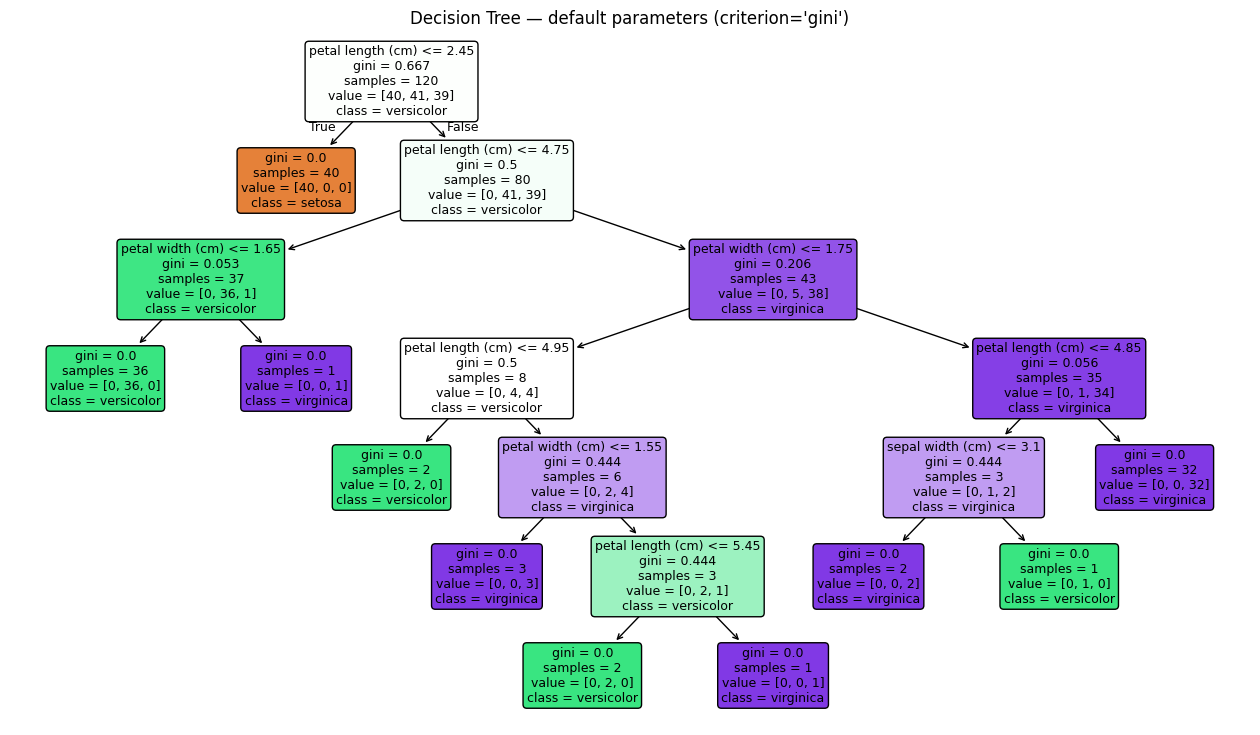

In [11]:
plt.figure(figsize=(16, 9))
plot_tree(clf,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree — default parameters (criterion='gini')")
plt.show()

In [12]:
print("Maximum depth      :", clf.get_depth())
print("Number of leaves   :", clf.get_n_leaves())
print("Total nodes        :", clf.tree_.node_count)
print("Internal nodes     :", clf.tree_.node_count - clf.get_n_leaves())
print("Root split feature :", iris.feature_names[clf.tree_.feature[0]])
print("Root threshold     :", round(clf.tree_.threshold[0], 3))

Maximum depth      : 6
Number of leaves   : 10
Total nodes        : 19
Internal nodes     : 9
Root split feature : petal length (cm)
Root threshold     : 2.45


In [13]:
importances = pd.Series(clf.feature_importances_, index=iris.feature_names)
print("Feature importances:")
print(importances.sort_values(ascending=False).round(4))

Feature importances:
petal length (cm)    0.9061
petal width (cm)     0.0772
sepal width (cm)     0.0167
sepal length (cm)    0.0000
dtype: float64


**Reading the visualisation**

- **Root node:** `petal length (cm) <= 2.45` (gini = 0.665, samples = 120)
- **Internal nodes:** the 9 nodes below the root that still have a split condition
- **Leaf nodes:** the 10 terminal boxes with gini = 0.0 and one predicted class
- **Maximum depth:** 6

**Why petal length was picked for the first split**

It gives the biggest drop in Gini impurity — a single cut at 2.45 cm separates every setosa sample cleanly in one step. The feature importances back this up: petal length scores 0.906 while sepal length contributes nothing at all.

## Task 5 — Comparing Gini Index and Entropy

In [14]:
rows = []
for criterion in ['gini', 'entropy']:
    model = DecisionTreeClassifier(criterion=criterion, random_state=42)
    model.fit(X_train, y_train)
    rows.append({
        'Criterion'   : criterion,
        'Accuracy'    : round(accuracy_score(y_test, model.predict(X_test)), 4),
        'Tree Depth'  : model.get_depth(),
        'Leaf Nodes'  : model.get_n_leaves(),
        'Root Feature': iris.feature_names[model.tree_.feature[0]],
        'Root Threshold': round(model.tree_.threshold[0], 3)
    })

criterion_df = pd.DataFrame(rows)
criterion_df

,Criterion,Accuracy,Tree Depth,Leaf Nodes,Root Feature,Root Threshold
0,gini,1.0,6,10,petal length (cm),2.45
1,entropy,1.0,6,10,petal length (cm),2.45


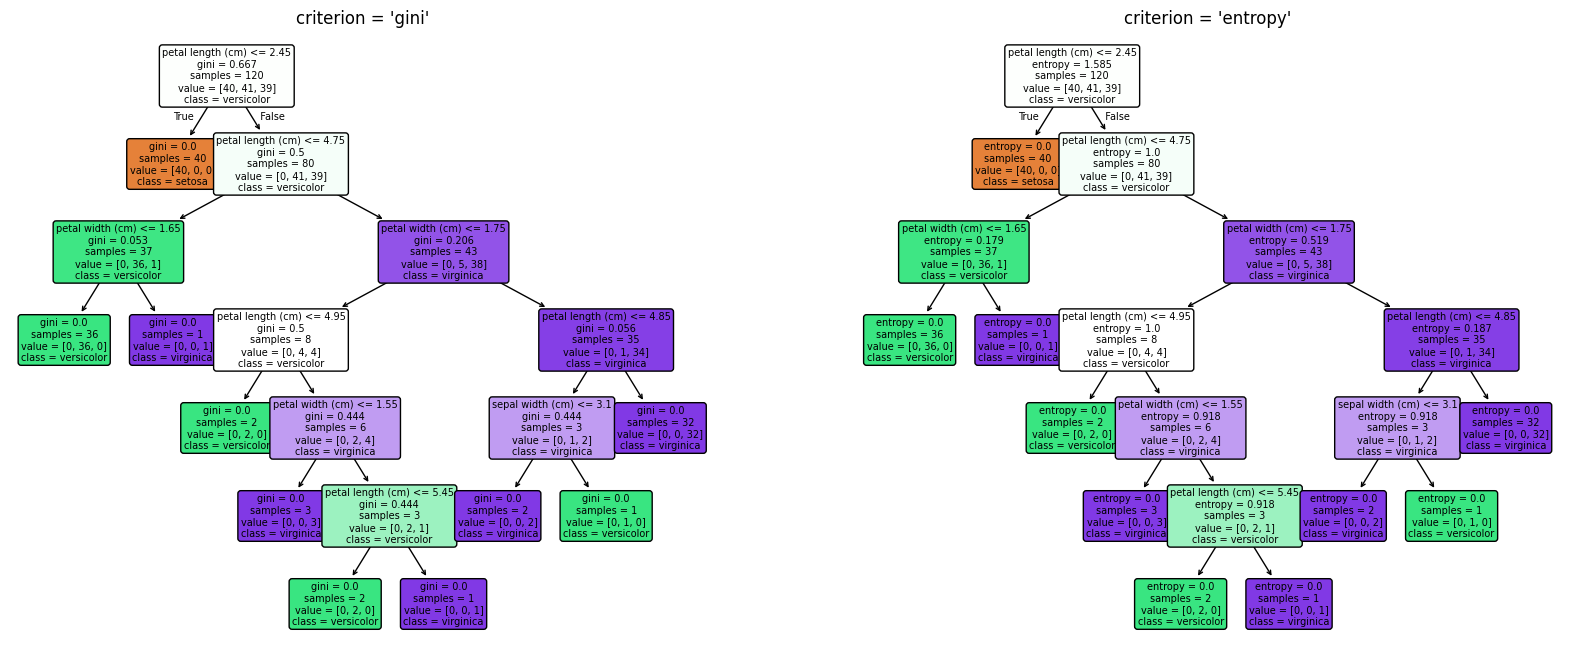

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, criterion in zip(axes, ['gini', 'entropy']):
    model = DecisionTreeClassifier(criterion=criterion, random_state=42).fit(X_train, y_train)
    plot_tree(model, feature_names=iris.feature_names, class_names=iris.target_names,
              filled=True, rounded=True, fontsize=7, ax=ax)
    ax.set_title(f"criterion = '{criterion}'")
plt.show()

**Observation**

Both criteria gave exactly the same tree — accuracy 1.00, depth 6, 10 leaves and the same root split at `petal length <= 2.45`. Neither is simpler; gini and entropy behave almost identically on a dataset this clean, and gini is just slightly cheaper to compute since it skips the logarithm.

## Task 6 — Effect of Maximum Tree Depth

In [16]:
rows = []
for depth in [1, 2, 3, 4, None]:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    rows.append({
        'Max Depth'        : str(depth),
        'Training Accuracy': round(accuracy_score(y_train, model.predict(X_train)), 4),
        'Testing Accuracy' : round(accuracy_score(y_test,  model.predict(X_test)), 4),
        'Tree Depth'       : model.get_depth(),
        'Leaf Nodes'       : model.get_n_leaves()
    })

depth_df = pd.DataFrame(rows)
depth_df

,Max Depth,Training Accuracy,Testing Accuracy,Tree Depth,Leaf Nodes
0,1,0.6750,0.6333,1,2
1,2,0.9500,0.9667,2,3
2,3,0.9583,1.0000,3,5
3,4,0.9750,1.0000,4,7
4,None,1.0000,1.0000,6,10


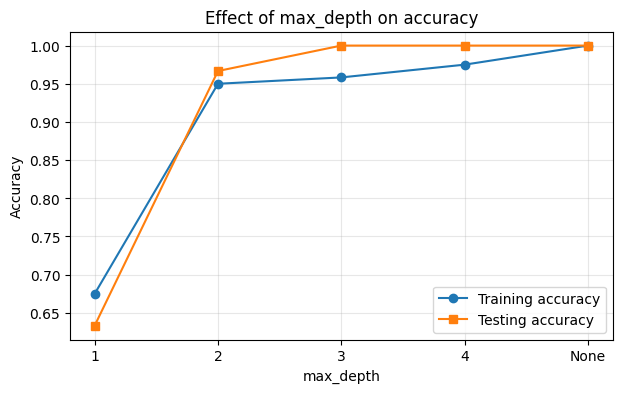

In [17]:
plt.figure(figsize=(7, 4))
x_labels = depth_df['Max Depth']
plt.plot(x_labels, depth_df['Training Accuracy'], marker='o', label='Training accuracy')
plt.plot(x_labels, depth_df['Testing Accuracy'],  marker='s', label='Testing accuracy')
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Effect of max_depth on accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

| Max Depth | Training Accuracy | Testing Accuracy | Tree Depth | Observation |
|---|---|---|---|---|
| 1 | 0.6750 | 0.6333 | 1 | Only setosa gets separated — both accuracies poor |
| 2 | 0.9500 | 0.9667 | 2 | Big jump; versicolor and virginica now split apart |
| 3 | 0.9583 | 1.0000 | 3 | Perfect test accuracy with a small tree |
| 4 | 0.9750 | 1.0000 | 4 | Test accuracy same as depth 3, just more branches |
| None | 1.0000 | 1.0000 | 6 | Fits training data perfectly but gains nothing on test |

**Which model is underfitting?** `max_depth=1` — one split can't handle three classes, so it only manages 63.33% on the test set.

**Which gives the best generalisation?** `max_depth=3` — the smallest tree that already hits 100% test accuracy.

**Which is likely to overfit?** `max_depth=None` — training accuracy is pushed to 100% by adding depth for a few borderline versicolor/virginica points, but test accuracy stops improving after depth 3, so that extra structure is fitting noise.

## Task 7 — Effect of `min_samples_split`

In [18]:
rows = []
for split in [2, 5, 10, 20]:
    model = DecisionTreeClassifier(min_samples_split=split, random_state=42)
    model.fit(X_train, y_train)
    rows.append({
        'min_samples_split': split,
        'Training Accuracy': round(accuracy_score(y_train, model.predict(X_train)), 4),
        'Accuracy (test)'  : round(accuracy_score(y_test,  model.predict(X_test)), 4),
        'Tree Depth'       : model.get_depth(),
        'Leaf Nodes'       : model.get_n_leaves()
    })

split_df = pd.DataFrame(rows)
split_df

,min_samples_split,Training Accuracy,Accuracy (test),Tree Depth,Leaf Nodes
0,2,1.0000,1.0,6,10
1,5,0.9833,1.0,5,8
2,10,0.9583,1.0,4,6
3,20,0.9583,1.0,4,6


| min_samples_split | Accuracy | Tree Depth | Leaf Nodes | Observation |
|---|---|---|---|---|
| 2 | 1.00 | 6 | 10 | Default — fully grown tree (train accuracy 1.000) |
| 5 | 1.00 | 5 | 8 | Tiny nodes stop splitting; train accuracy 0.983 |
| 10 | 1.00 | 4 | 6 | Clearly simpler tree; train accuracy 0.958 |
| 20 | 1.00 | 4 | 6 | No change — no node was left with 10–19 samples |

**Effect on complexity**

Raising `min_samples_split` stops small nodes from splitting further, so depth and leaf count both shrink while test accuracy stays at 1.00. Past a point (10 → 20) the constraint stops binding and the tree stays the same.

## Task 8 — Effect of `min_samples_leaf`

In [19]:
rows = []
for leaf in [1, 2, 5, 10]:
    model = DecisionTreeClassifier(min_samples_leaf=leaf, random_state=42)
    model.fit(X_train, y_train)
    rows.append({
        'min_samples_leaf' : leaf,
        'Training Accuracy': round(accuracy_score(y_train, model.predict(X_train)), 4),
        'Accuracy (test)'  : round(accuracy_score(y_test,  model.predict(X_test)), 4),
        'Tree Depth'       : model.get_depth(),
        'Leaf Nodes'       : model.get_n_leaves()
    })

leaf_df = pd.DataFrame(rows)
leaf_df

,min_samples_leaf,Training Accuracy,Accuracy (test),Tree Depth,Leaf Nodes
0,1,1.000,1.0000,6,10
1,2,0.975,1.0000,5,8
2,5,0.950,1.0000,4,6
3,10,0.950,0.9667,4,6


| min_samples_leaf | Accuracy | Tree Depth | Leaf Nodes | Observation |
|---|---|---|---|---|
| 1 | 1.0000 | 6 | 10 | Default — leaves can hold a single sample |
| 2 | 1.0000 | 5 | 8 | Single-sample leaves gone; train accuracy 0.975 |
| 5 | 1.0000 | 4 | 6 | Simpler tree, test accuracy still perfect |
| 10 | 0.9667 | 4 | 6 | Same shape but coarser leaves — accuracy drops |

**Influence on overfitting**

Forcing a minimum number of samples per leaf stops the tree from carving out a branch for one or two odd points, which is exactly what overfitting looks like. Training accuracy drops from 1.000 to 0.950 while test accuracy holds up to 5, but at 10 it goes too far and starts underfitting.

## Task 9 — Conceptual Questions

**1. What is the role of the `criterion` parameter?**

It decides the impurity measure used to score candidate splits — `gini` uses 1 − Σpᵢ², `entropy` uses −Σpᵢ log₂ pᵢ. It controls *how* splits are chosen, not how many the tree makes.

**2. How does `max_depth` influence underfitting and overfitting?**

Too small and the tree is too coarse to draw the class boundaries (depth 1 gave only 63.33% test accuracy); left unlimited it keeps splitting until every leaf is pure and starts memorising individual points. The sweet spot is where test accuracy flattens out — depth 3 here.

**3. Why do larger `min_samples_split` and `min_samples_leaf` produce simpler trees?**

Deeper nodes naturally hold fewer samples, so demanding a minimum count makes those nodes ineligible to split and turns them into leaves. Tasks 7 and 8 show this clearly — both cut depth from 6 to 4 and leaves from 10 to 6.

**4. Which hyperparameter had the greatest impact?**

`max_depth`, by a wide margin — it swung test accuracy from 0.6333 to 1.00, while `min_samples_split` never changed it and `criterion` made no difference at all. It's the only one that controls both the underfitting and overfitting ends; the others just trim redundant branches.

**5. Recommended model**

`DecisionTreeClassifier(criterion='gini', max_depth=3, min_samples_leaf=5, random_state=42)` — it matches the fully grown tree's 1.00 test accuracy using only depth 3 and 5 leaves instead of depth 6 and 10, so it is far easier to read and less tied to this particular split.

One caveat: 100% on just 30 test samples flatters every model here. The 5-fold CV below gives 0.9533 for the default tree and 0.9400 for the recommended one — well within one standard deviation, so the extra depth buys no real accuracy and the simpler tree is still the better pick.

In [20]:
final_model = DecisionTreeClassifier(criterion='gini', max_depth=3,
                                     min_samples_leaf=5, random_state=42)
final_model.fit(X_train, y_train)
final_pred = final_model.predict(X_test)

print("Test accuracy    :", accuracy_score(y_test, final_pred))
print("Tree depth       :", final_model.get_depth())
print("Number of leaves :", final_model.get_n_leaves())
print()
print(classification_report(y_test, final_pred, target_names=iris.target_names))

Test accuracy    : 1.0
Tree depth       : 3
Number of leaves : 5

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [21]:
from sklearn.model_selection import cross_val_score

for name, model in [("Fully grown (default)", DecisionTreeClassifier(random_state=42)),
                    ("Recommended model", DecisionTreeClassifier(criterion='gini', max_depth=3,
                                                                 min_samples_leaf=5, random_state=42))]:
    scores = cross_val_score(model, X, y, cv=5)
    print(f"{name:22s} 5-fold CV accuracy = {scores.mean():.4f} (+/- {scores.std():.4f})")

Fully grown (default)  5-fold CV accuracy = 0.9533 (+/- 0.0340)
Recommended model      5-fold CV accuracy = 0.9400 (+/- 0.0611)


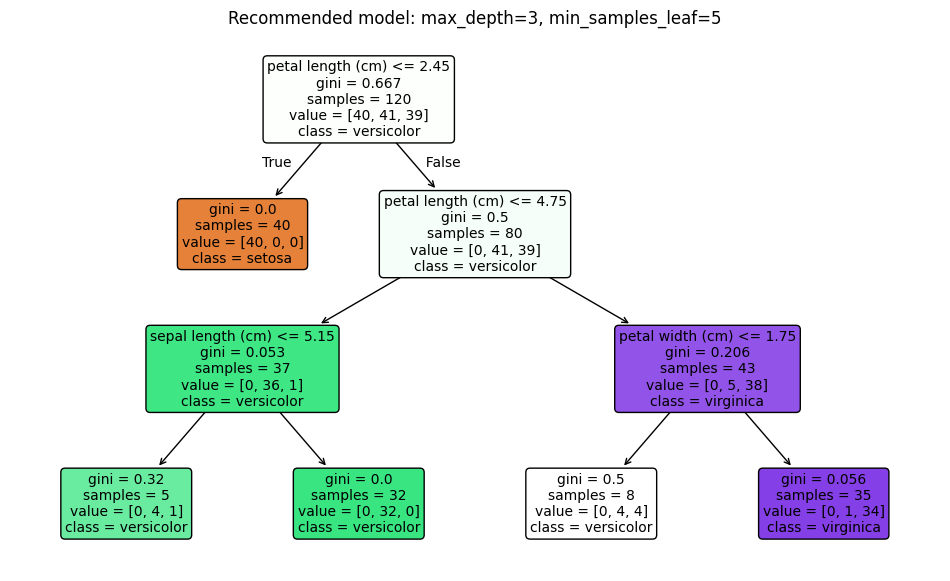

In [22]:
plt.figure(figsize=(12, 7))
plot_tree(final_model,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True, rounded=True, fontsize=10)
plt.title("Recommended model: max_depth=3, min_samples_leaf=5")
plt.show()